In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
# from gsmo.hist_features_uni import extract_embeddings, extract_patch, get_embeddings_uni2
from gsmo.utils import *
from gsmo import GSMO, GSMOConfig
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import random

seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")


CUDA is available. GPU: NVIDIA GeForce RTX 3090


In [2]:
import os
os.chdir('data/metabolism')

In [3]:
rna = sc.read("RNA_SAM_1000.h5ad")
meta = sc.read("MALDI_SAM_1000.h5ad")
print(rna.shape, meta.shape)
print(rna.obsm['spatial'].shape)

(10759, 1000) (10759, 1000)
(10759, 2)


In [4]:
img = Image.open("spatial/tissue_hires_image.png")
img = img.convert("RGB")
img_np = np.array(img)
print(img_np.shape)  # (H, W, 3)


(2000, 1988, 3)


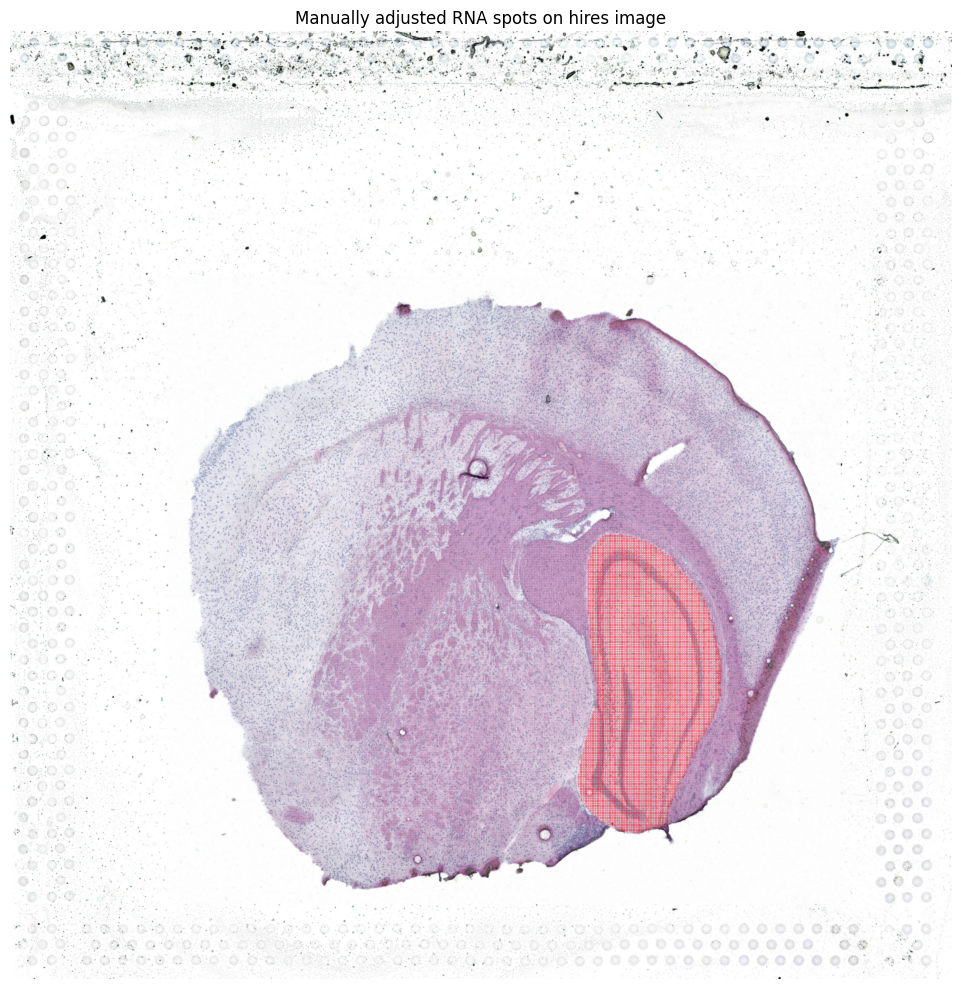

In [5]:
img = Image.open("spatial/tissue_hires_image.png").convert("RGB")
img_np = np.array(img)


a = sc.read("RNA_SAM_256.h5ad")
rna_coords = a.obsm['spatial']

manual_scale = 0.996  
manual_shift = np.array([8, 11])  

coords_fullres = rna_coords  
coords_hires = (coords_fullres + manual_shift) * manual_scale / 0.4416717


plt.figure(figsize=(10, 10))
plt.imshow(img_np)
plt.scatter(coords_hires[:, 0], coords_hires[:, 1], s=0.2, c='red', alpha=0.3)
plt.title("Manually adjusted RNA spots on hires image")
plt.axis("off")
plt.tight_layout()
# plt.savefig("sam_plot.png", dpi=600)
plt.show()



In [ ]:
from tqdm import tqdm

def extract_patch_safe(img, center_x, center_y, patch_size):

    h, w, _ = img.shape
    patch = np.ones((patch_size, patch_size, 3), dtype=np.uint8) * 255  

    half = patch_size // 2
    start_x = center_x - half
    start_y = center_y - half
    end_x = center_x + half
    end_y = center_y + half

    img_x1 = int(max(start_x, 0))
    img_x2 = int(min(end_x, w))
    img_y1 = int(max(start_y, 0))
    img_y2 = int(min(end_y, h))

    patch_x1 = int(img_x1 - start_x)
    patch_x2 = int(patch_x1 + (img_x2 - img_x1))
    patch_y1 = int(img_y1 - start_y)
    patch_y2 = int(patch_y1 + (img_y2 - img_y1))

    patch[patch_y1:patch_y2, patch_x1:patch_x2] = img[img_y1:img_y2, img_x1:img_x2]
    return patch

def extract_embeddings_batch_dualscale(
    img,
    coords_img,
    patch_sizes=(24, 32),
    batch_size=128,
    device='cuda'
):
    import torch
    import numpy as np
    from PIL import Image
    from tqdm import tqdm
    from gsmo.hist_features_uni import model, transform

    if isinstance(img, Image.Image):
        img = np.array(img.convert("RGB"))

    model.eval()
    model.to(device)

    embeddings = []

    with torch.inference_mode():
        for i in tqdm(range(0, len(coords_img), batch_size), desc="Extracting dual-scale embeddings"):
            coords_batch = coords_img[i:i+batch_size]

            patches_small = [extract_patch_safe(img, int(x), int(y), patch_sizes[0]) for (x, y) in coords_batch]
            patches_large = [extract_patch_safe(img, int(x), int(y), patch_sizes[1]) for (x, y) in coords_batch]

            batch_s = torch.stack([transform(Image.fromarray(p)) for p in patches_small]).to(device)
            batch_l = torch.stack([transform(Image.fromarray(p)) for p in patches_large]).to(device)

            emb_s = model(batch_s).cpu().numpy()  # [B, 1536]
            emb_l = model(batch_l).cpu().numpy()  # [B, 1536]

            emb = np.concatenate([emb_s, emb_l], axis=1)  # [B, 3072]
            embeddings.append(emb)

    return np.concatenate(embeddings, axis=0)



embeddings = extract_embeddings_batch_dualscale(
    img=img,
    coords_img=coords_hires,
    patch_sizes=(8, 24), 
    batch_size=256,
    device='cuda'
)

print("embedding shape:", embeddings.shape)  # [N, 3072]

np.save("image_embeddings.npy", embeddings)


Extracting dual-scale embeddings: 100%|██████████| 43/43 [09:44<00:00, 13.60s/it]


embedding shape: (10759, 3072)


In [6]:
from sklearn.preprocessing import StandardScaler

image_embeddings = np.load("image_embeddings.npy")  # [N, 1536]
assert image_embeddings.shape[0] == rna.shape[0]

rna = preprocess(rna, modality="rna")
meta = preprocess(meta, modality="metabolite")

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [7]:
import torch.nn as nn
features_dict = {
        'rna': rna,       
        'metabolite': meta,      
        'image': image_embeddings     
    }

initial_weights = [1.0, 1.0, 1.0]  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg = GSMOConfig
model = GSMO(features_dict, spatial_coords=coords_hires, device=device, cfg=cfg, trainable_weights=True, initial_weights=initial_weights)
model.load_state_dict(torch.load("best_model.pth"))



/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


<All keys matched successfully>

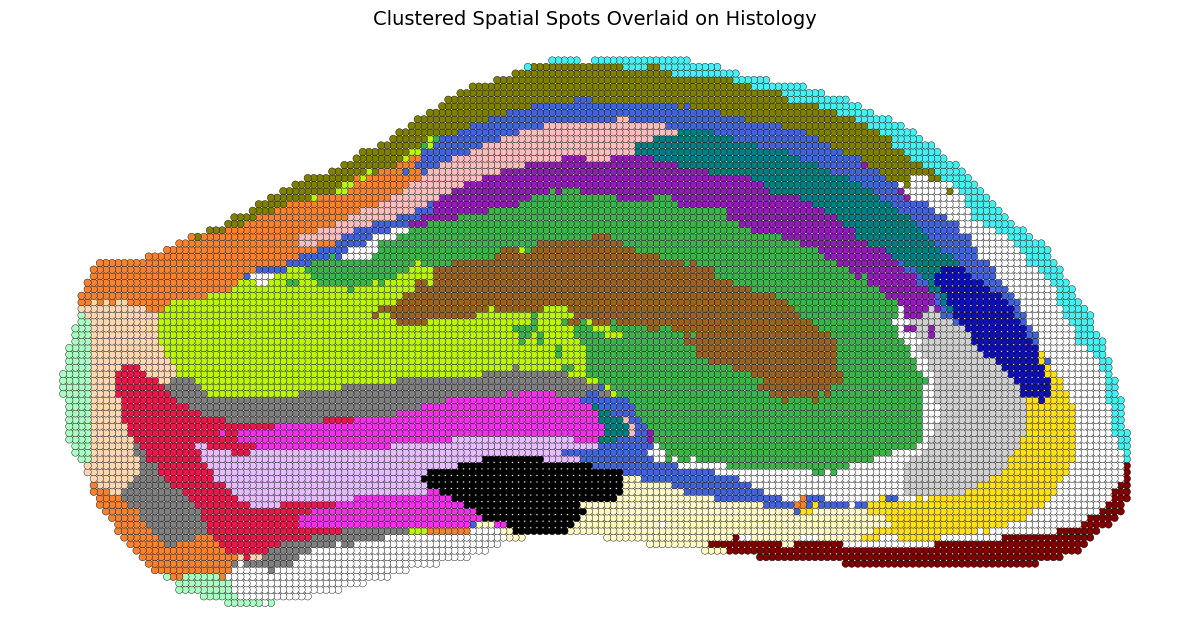

In [8]:
from matplotlib.colors import ListedColormap


coords_img = coords_hires
clusters = model.cluster_kmeans(n_clusters=23)

plot_color = ['#808080', '#3cb44b', '#ffe119', '#4363d8', '#f032e6', '#911eb4', '#46f0f0', '#f58231', 
              '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#ffd8b1', '#800000', '#aaffc3', 
              '#808000', '#0F0FB6', '#000000', '#e6194b', '#ffffff', '#fffac8', '#D1D1D1']  

num_clusters = len(np.unique(clusters))
if num_clusters > len(plot_color):
    raise ValueError(f"Cluster number {num_clusters} exceeds the number of colors available in the custom palette {len(plot_color)}.")
cmap = ListedColormap(plot_color[:num_clusters])

plt.figure(figsize=(12, 6.5))

scatter = plt.scatter(
    -coords_hires[:, 1], coords_hires[:, 0],
    c=clusters,
    cmap=cmap,
    s=28,
    alpha=1,
    edgecolors='k',
    linewidths=0.3
)

plt.title("Clustered Spatial Spots Overlaid on Histology", fontsize=14)
plt.axis('off')
plt.tight_layout()

# plt.savefig("our_clusters.png", dpi=600, bbox_inches='tight')
plt.show()



In [ ]:
# two unsupervised metrics

from sklearn.metrics import pairwise_distances

def compute_jaccard_similarity(Z_m, Z_e, k=50):
    dist_m = pairwise_distances(Z_m)
    dist_e = pairwise_distances(Z_e)
    
    n = Z_m.shape[0]
    jaccard_scores = []

    for i in tqdm(range(n), desc="Calculating Jaccard similarities"):
        neighbors_m = set(np.argsort(dist_m[i])[1:k+1])  # exclude self
        neighbors_e = set(np.argsort(dist_e[i])[1:k+1])
        intersection = len(neighbors_m & neighbors_e)
        union = len(neighbors_m | neighbors_e)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_scores.append(jaccard)

    return np.array(jaccard_scores), np.mean(jaccard_scores)


import squidpy as sq


def compute_morans_I(labels, spatial_coords, label_name="cluster_label"):

    adata = sc.AnnData(X=np.zeros((len(labels), 1)))  # dummy
    adata.obs[label_name] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    sq.gr.spatial_autocorr(adata, mode="moran", genes=label_name, attr="obs")

    moran_result = adata.uns["moranI"].loc[label_name, "I"]
    return moran_result



fused_embeddings = model.get_embeddings()


# 1. Jaccard
jaccard_all, jaccard_mean = compute_jaccard_similarity(rna, fused_embeddings, k=50)
print(f"Mean Jaccard RNA Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(meta, fused_embeddings, k=50)
print(f"Mean Jaccard meta Similarity: {jaccard_mean:.4f}")


# from sklearn.decomposition import PCA
# img_pca_50 = PCA(n_components=576).fit_transform(image_embeddings)

jaccard_all, jaccard_mean = compute_jaccard_similarity(image_embeddings, fused_embeddings, k=50)
print(f"Mean Jaccard image Similarity: {jaccard_mean:.4f}")

cluster_labels = clusters
morans_I = compute_morans_I(cluster_labels, coords_hires)
print(f"Moran's I score: {morans_I:.4f}")



/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
Calculating Jaccard similarities: 100%|██████████| 10759/10759 [00:07<00:00, 1365.51it/s]


Mean Jaccard RNA Similarity: 0.3307


Calculating Jaccard similarities: 100%|██████████| 10759/10759 [00:07<00:00, 1405.72it/s]


Mean Jaccard meta Similarity: 0.4199


Calculating Jaccard similarities: 100%|██████████| 10759/10759 [00:07<00:00, 1378.04it/s]


Mean Jaccard image Similarity: 0.1701
Moran's I score: 0.8202


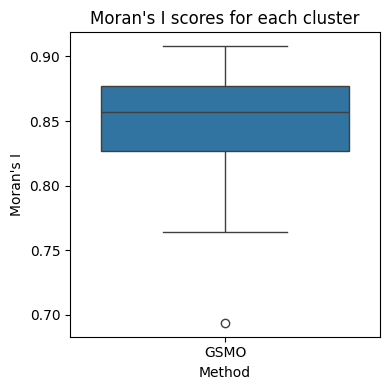

   cluster   moran_I method
0        0  0.764034   GSMO
1        1  0.887954   GSMO
2        2  0.850554   GSMO
3        3  0.693722   GSMO
4        4  0.824222   GSMO
5        5  0.828727   GSMO
6        6  0.818649   GSMO
7        7  0.856717   GSMO
8        8  0.879406   GSMO
9        9  0.796664   GSMO
10      10  0.830086   GSMO
11      11  0.861389   GSMO
12      12  0.907927   GSMO
13      13  0.862552   GSMO
14      14  0.877720   GSMO
15      15  0.877130   GSMO
16      16  0.854427   GSMO
17      17  0.863612   GSMO
18      18  0.894158   GSMO
19      19  0.832892   GSMO
20      20  0.786652   GSMO
21      21  0.866789   GSMO
22      22  0.903219   GSMO


In [12]:
# box plot of moran's I
import squidpy as sq
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_morans_I_per_method(labels, spatial_coords, method_name="MethodA"):
    adata = sc.AnnData(X=np.zeros((len(labels), 1)))
    adata.obs["cluster_label"] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    moran_scores = []
    unique_labels = np.unique(labels)

    for label in unique_labels:
        binary_vector = (labels == label).astype(int)
        adata.obs["tmp_binary"] = binary_vector

        sq.gr.spatial_autocorr(adata, mode="moran", genes="tmp_binary", attr="obs")
        I_score = adata.uns["moranI"].loc["tmp_binary", "I"]
        moran_scores.append({
            "cluster": str(label),
            "moran_I": I_score,
            "method": method_name
        })

    df_moran = pd.DataFrame(moran_scores)

    plt.figure(figsize=(4, 4))
    sns.boxplot(data=df_moran, x="method", y="moran_I")
    plt.title("Moran's I scores for each cluster")
    plt.ylabel("Moran's I")
    plt.xlabel("Method")
    plt.tight_layout()
    plt.show()

    return df_moran

morans_I_df = compute_morans_I_per_method(cluster_labels, coords_hires, method_name="GSMO")
print(morans_I_df)


/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:435: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:437: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:440: PerformanceWarning:

共选出 33 个 DEG 基因


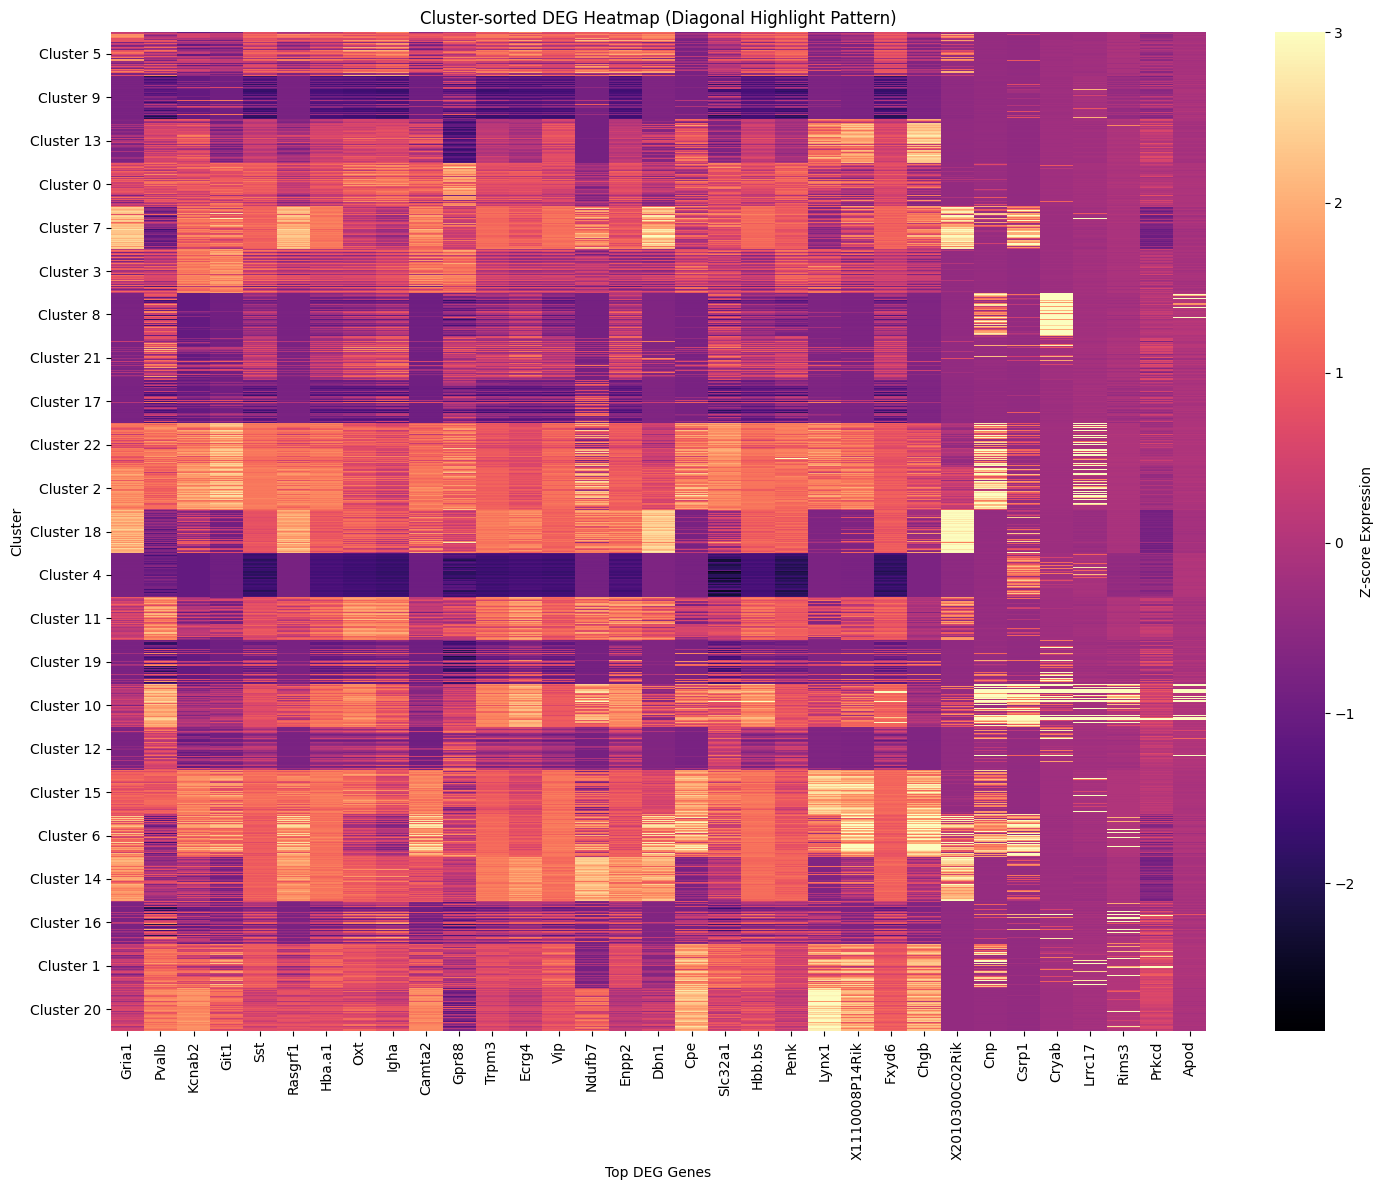

In [ ]:
# heat map of cell-level DEG
import seaborn as sns 
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
rna = sc.read("RNA_SAM_1000.h5ad")
adata = rna.copy()
clusters = model.cluster_kmeans(n_clusters=23)
adata.obs['GSMO'] = pd.Categorical(clusters)

sc.tl.rank_genes_groups(adata, groupby='GSMO', method='t-test', n_genes=100)
deg_results = adata.uns['rank_genes_groups']


deg_df = pd.DataFrame(deg_results['names']).T
top_genes = pd.unique(deg_df.iloc[:, :2].values.ravel())  # top 3 per cluster
print(f"共选出 {len(top_genes)} 个 DEG 基因")

adata_deg = adata[:, top_genes].copy()
expr = adata_deg.X
if not isinstance(expr, np.ndarray):
    expr = expr.toarray()
expr_z = (expr - np.mean(expr, axis=0)) / np.std(expr, axis=0)
expr_scaled = np.clip(expr_z, -3, 3)

expr_df = pd.DataFrame(expr_scaled, columns=top_genes, index=adata.obs_names)
expr_df['cluster'] = adata.obs['GSMO'].values

gene_order = expr_df.drop(columns='cluster').var().sort_values(ascending=False).index.tolist()

cluster_means = expr_df.groupby('cluster').mean()[gene_order]

cluster_peak_indices = cluster_means.values.argmax(axis=1)
cluster_peak_map = dict(zip(cluster_means.index, cluster_peak_indices))

cluster_order = sorted(cluster_means.index, key=lambda c: cluster_peak_map[c])

gene_order = expr_df.drop(columns='cluster').var().sort_values(ascending=False).index.tolist()

n_cells_per_cluster = 600
clustered_dfs = []

for cluster in cluster_order:
    cluster_df = expr_df[expr_df['cluster'] == cluster].drop(columns='cluster')
    if len(cluster_df) >= n_cells_per_cluster:
        sampled = cluster_df.sample(n=n_cells_per_cluster, random_state=0)
    else:
        sampled = cluster_df.sample(n=n_cells_per_cluster, replace=True, random_state=0)
    sampled['cluster'] = cluster
    clustered_dfs.append(sampled)

uniform_df = pd.concat(clustered_dfs)
uniform_df_sorted = uniform_df.sort_values(by='cluster')
uniform_df_clean = uniform_df_sorted.drop(columns='cluster')[gene_order] 

plt.figure(figsize=(15, 12))
cmap = LinearSegmentedColormap.from_list("custom_magma", ["#ffffff", "#d3d3d3", "#ff1919"])

sns.heatmap(uniform_df_clean, cmap='magma', annot=False,
            cbar_kws={'label': 'Z-score Expression'},
            xticklabels=True, yticklabels=False, linewidths=0)

ax = plt.gca()
cluster_labels = uniform_df_sorted['cluster'].values
cluster_start = 0
cluster_centers = []

for cluster in cluster_order:
    cluster_end = cluster_start + n_cells_per_cluster - 1
    ax.add_patch(Rectangle((0, cluster_start), len(uniform_df_clean.columns), n_cells_per_cluster,
                           linewidth=0, edgecolor='white', facecolor='none'))
    center = (cluster_start + cluster_end) // 2
    cluster_centers.append((center, cluster))  
    cluster_start = cluster_end + 1

ax.set_yticks([c[0] for c in cluster_centers])
ax.set_yticklabels([f'Cluster {c[1]}' for c in cluster_centers], fontsize=10)

plt.title("Cluster-sorted DEG Heatmap (Diagonal Highlight Pattern)")
plt.xlabel("Top DEG Genes")
plt.ylabel("Cluster")
plt.tight_layout()
# plt.savefig("DEG_heatmap_diag_sorted.png", dpi=600, bbox_inches='tight')
plt.show()


/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/user2/anaconda3

共选出 41 个差异性代谢物


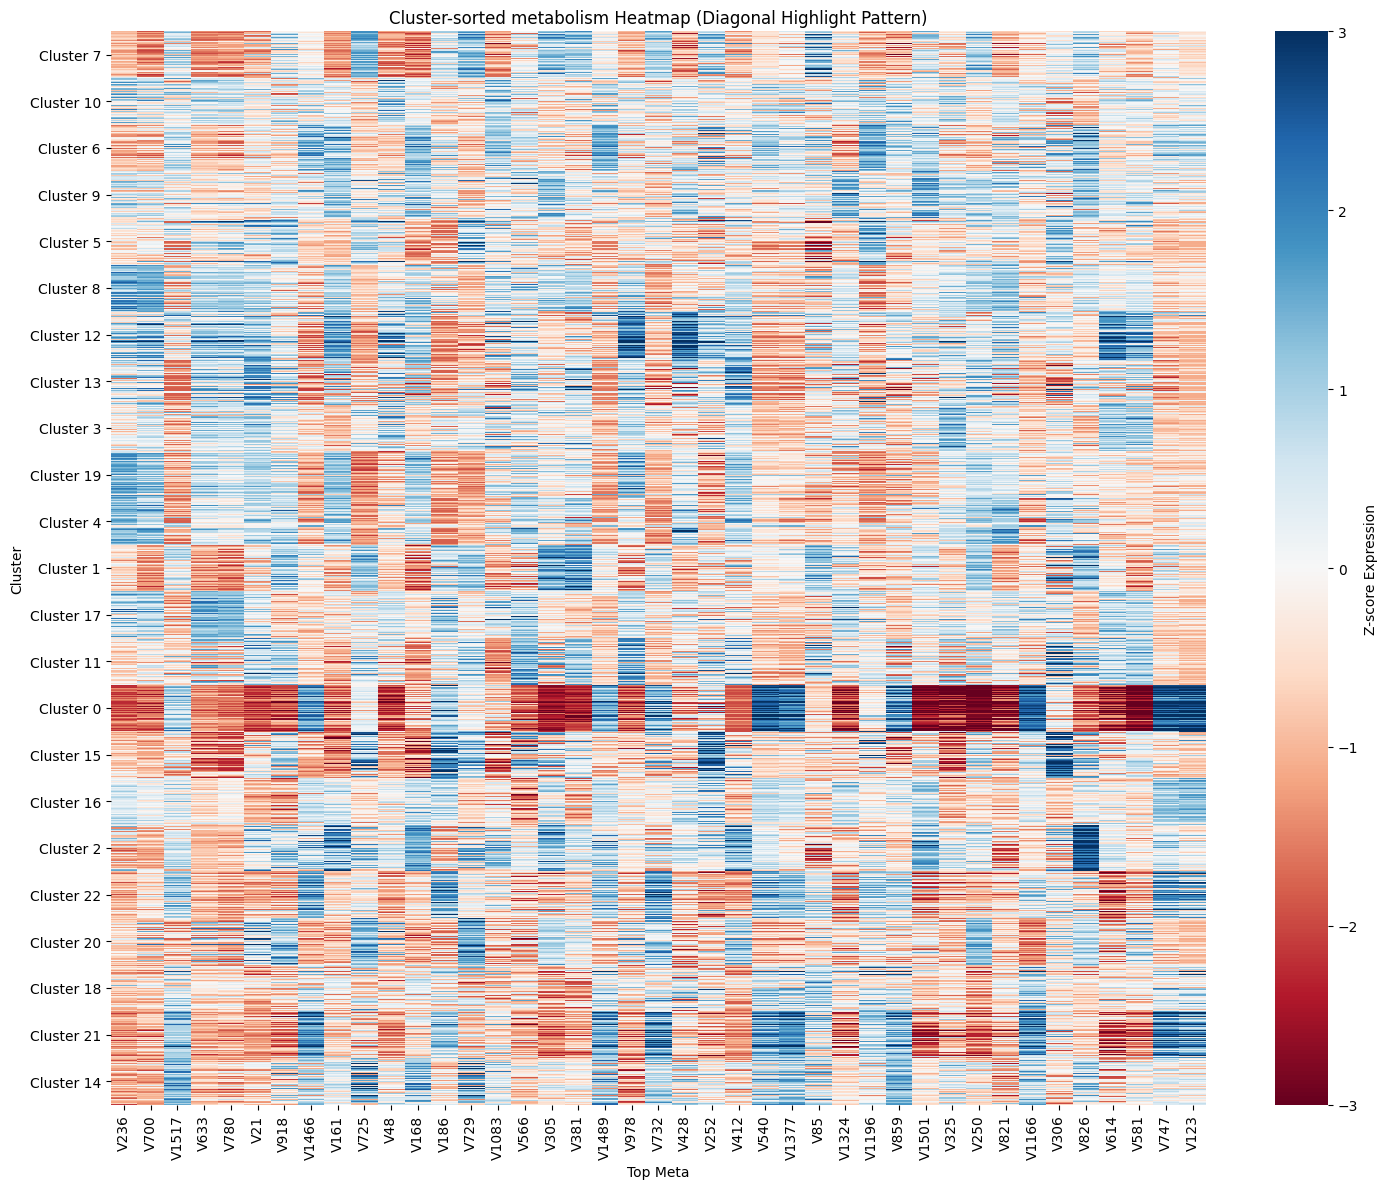

In [14]:
# heat map of cell-level expressions of metabolites

import seaborn as sns 
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
meta = sc.read("MALDI_SAM_1000.h5ad")

adata = meta.copy()
clusters = model.cluster_kmeans(n_clusters=23)
adata.obs['GSMO'] = pd.Categorical(clusters)

sc.tl.rank_genes_groups(adata, groupby='GSMO', method='t-test', n_genes=100)
deg_results = adata.uns['rank_genes_groups']

deg_df = pd.DataFrame(deg_results['names']).T
top_genes = pd.unique(deg_df.iloc[:, :2].values.ravel())  # top 3 per cluster
print(f"共选出 {len(top_genes)} 个差异性代谢物")

adata_deg = adata[:, top_genes].copy()
expr = adata_deg.X
if not isinstance(expr, np.ndarray):
    expr = expr.toarray()
expr_z = (expr - np.mean(expr, axis=0)) / np.std(expr, axis=0)
expr_scaled = np.clip(expr_z, -3, 3)

expr_df = pd.DataFrame(expr_scaled, columns=top_genes, index=adata.obs_names)
expr_df['cluster'] = adata.obs['GSMO'].values

cluster_means = expr_df.groupby('cluster').mean()
from sklearn.decomposition import PCA
pca = PCA(n_components=1).fit_transform(cluster_means)
cluster_order = pd.Series(pca[:, 0], index=cluster_means.index).sort_values().index.tolist()

gene_order = expr_df.drop(columns='cluster').var().sort_values(ascending=False).index.tolist()

n_cells_per_cluster = 600
clustered_dfs = []

for cluster in cluster_order:
    cluster_df = expr_df[expr_df['cluster'] == cluster].drop(columns='cluster')
    if len(cluster_df) >= n_cells_per_cluster:
        sampled = cluster_df.sample(n=n_cells_per_cluster, random_state=0)
    else:
        sampled = cluster_df.sample(n=n_cells_per_cluster, replace=True, random_state=0)
    sampled['cluster'] = cluster
    clustered_dfs.append(sampled)

uniform_df = pd.concat(clustered_dfs)
uniform_df_sorted = uniform_df.sort_values(by='cluster')
uniform_df_clean = uniform_df_sorted.drop(columns='cluster')[gene_order]  

plt.figure(figsize=(15, 12))


sns.heatmap(uniform_df_clean, cmap='RdBu', annot=False,
            cbar_kws={'label': 'Z-score Expression'},
            xticklabels=True, yticklabels=False, linewidths=0)

ax = plt.gca()
cluster_labels = uniform_df_sorted['cluster'].values
cluster_start = 0
cluster_centers = []

for cluster in cluster_order:
    cluster_end = cluster_start + n_cells_per_cluster - 1
    ax.add_patch(Rectangle((0, cluster_start), len(uniform_df_clean.columns), n_cells_per_cluster,
                           linewidth=0, edgecolor='white', facecolor='none'))
    center = (cluster_start + cluster_end) // 2
    cluster_centers.append((center, cluster))  
    cluster_start = cluster_end + 1

ax.set_yticks([c[0] for c in cluster_centers])
ax.set_yticklabels([f'Cluster {c[1]}' for c in cluster_centers], fontsize=10)

plt.title("Cluster-sorted metabolism Heatmap (Diagonal Highlight Pattern)")
plt.xlabel("Top Meta")
plt.ylabel("Cluster")
plt.tight_layout()
# plt.savefig("Meta_heatmap_diag_sorted.png", dpi=600, bbox_inches='tight')
plt.show()


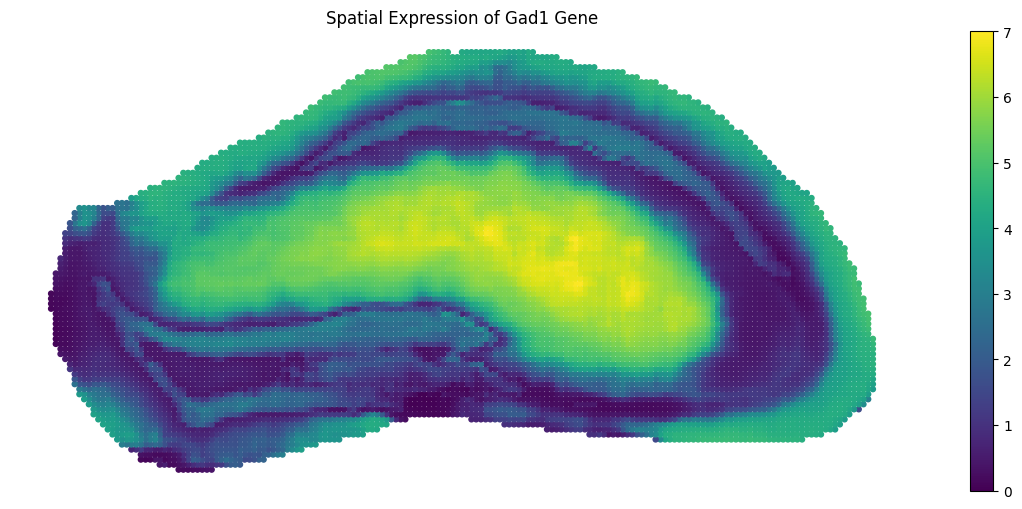

In [15]:
# heat map of expressions of selected genes
# Gad1 and Aldoc
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

rna = sc.read("RNA_SAM_1000.h5ad")
meta = sc.read("MALDI_SAM_1000.h5ad")


adata_p = rna
sc.pp.normalize_total(adata_p, target_sum=1e4) 
sc.pp.scale(adata_p, zero_center=True) 


if 'Gad1' not in adata_p.var_names:
    print("The Gad1 gene is not present in the dataset. Please confirm whether the Gad1 gene exists in the data")
else:
    cux1_expression = adata_p[:, 'Gad1'].X.toarray().flatten()  
    cux1_expression_zscore = (cux1_expression - np.mean(cux1_expression)) / np.std(cux1_expression)
    scaled_cux1 = np.interp(cux1_expression_zscore, (cux1_expression_zscore.min(), cux1_expression_zscore.max()), (0, 7))

    x = -coords_hires[:, 1]
    y = coords_hires[:, 0]

    plt.figure(figsize=(11.6, 5.2))
    scatter = plt.scatter(x, y, c=scaled_cux1, cmap='viridis', s=13, alpha=1.0)
    plt.colorbar(scatter)
    plt.title("Spatial Expression of Gad1 Gene")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
